# Análisis de Correlación Estadistica

El propósito de este estudio es profundizar en las relaciones lineales y no lineales existentes entre las características del conjunto de datos y los costos médicos (`charges`). Se busca identificar qué factores presentan un impacto estadístico mayor, aislar variables con baja o nula asociación lineal, y contrastar la distribución de los cargos en función de los principales grupos categóricos del dataset.

## 1. Preparación de los datos

Antes de calcular nada tenemos que dejar todo en formato numérico. El detalle es que tres variables (`sex`, `smoker` y `region`) vienen como texto, y la correlación no sabe qué hacer con palabras. Así que las convertimos:

- `sex` y `smoker` son de dos categorías, entonces las pasamos directo a 0 y 1.
- `region` tiene cuatro categorías, así que usamos codificación *one-hot* con `pd.get_dummies`, que crea una columna por región. Le ponemos `drop_first=True` para quitar una de esas columnas y no caer en la "trampa de las variables dummy", que es cuando una columna se puede deducir de las otras y termina metiendo información repetida.

Todo eso lo guardamos en `df_numerico` y dejamos el dataset original sin tocar.

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

# Carpeta de salida para las figuras
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Carga del dataset y replicación del preprocesamiento
df = pd.read_csv("../data/insurance.csv").drop_duplicates().reset_index(drop=True)

df_numerico = df.copy()
df_numerico["sex"] = df_numerico["sex"].map({"male": 0, "female": 1})
df_numerico["smoker"] = df_numerico["smoker"].map({"no": 0, "yes": 1})
df_numerico = pd.get_dummies(df_numerico, columns=["region"], drop_first=True, dtype=int)

print(f"Dataframe numérico listo para análisis: {df_numerico.shape[0]} registros.")

Dataframe numérico listo para análisis: 1337 registros.


## 2. Matriz de correlación (Pearson)

Se calcula el coeficiente de correlación de Pearson entre todas las variables disponibles y se genera un mapa de calor con un formato optimizado para evaluar las magnitudes de asociación lineal.

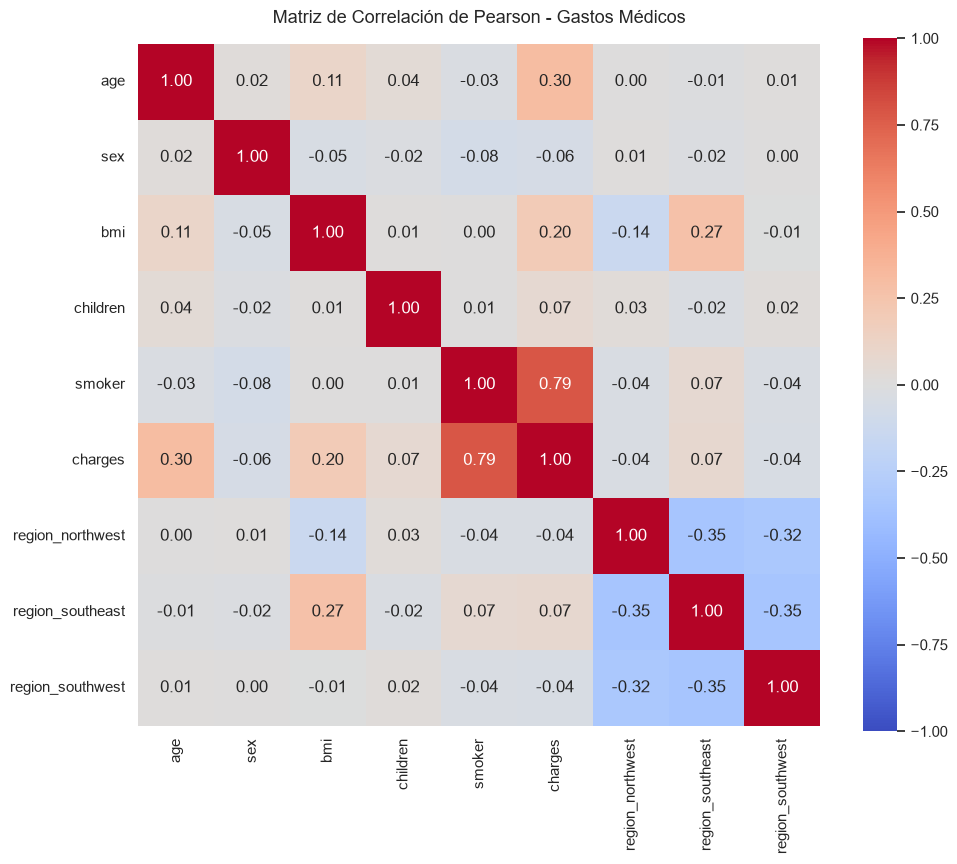

In [5]:
corr_pearson = df_numerico.corr(method="pearson")

plt.figure(figsize=(11, 9))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de Correlación de Pearson - Gastos Médicos", fontsize=13, pad=15)

plt.savefig(f"{FIG_DIR}/07_heatmap_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Cálculos de correlación
ranking = corr_pearson["charges"].sort_values(ascending=False)
corr_spearman = df_numerico.corr(method="spearman")
r_pb, p_pb = stats.pointbiserialr(df_numerico["smoker"], df_numerico["charges"])

# Impresión de resultados organizados
print("Ranking de correlación de Pearson con charges:")
print(ranking.round(3), "\n")

print("Ranking de correlación de Spearman con charges:")
print(corr_spearman["charges"].sort_values(ascending=False).round(3), "\n")

print(f"Correlación punto-biserial (smoker vs charges): r = {r_pb:.3f}")
print(f"p-value: {p_pb:.3e}")

Ranking de correlación de Pearson con charges:
charges             1.000
smoker              0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
region_northwest   -0.039
region_southwest   -0.044
sex                -0.058
Name: charges, dtype: float64 

Ranking de correlación de Spearman con charges:
charges             1.000
smoker              0.664
age                 0.534
children            0.132
bmi                 0.120
region_southeast    0.017
sex                -0.011
region_northwest   -0.020
region_southwest   -0.043
Name: charges, dtype: float64 

Correlación punto-biserial (smoker vs charges): r = 0.787
p-value: 1.407e-282


El coeficiente sale 0.79, igual que en Pearson como esperábamos, y el p-value es prácticamente cero. Ese p-value tan chiquito quiere decir que la relación entre fumar y los cargos es estadísticamente significativa, o sea que no es casualidad. Como referencia se usa el umbral de 0.05, y nosotros estamos muchísimo por debajo.

## 3. Comparación de `charges` por grupo

A continuación se visualiza la distribución de `charges` según `smoker`, `sex` y `region` para contextualizar los resultados de correlación.

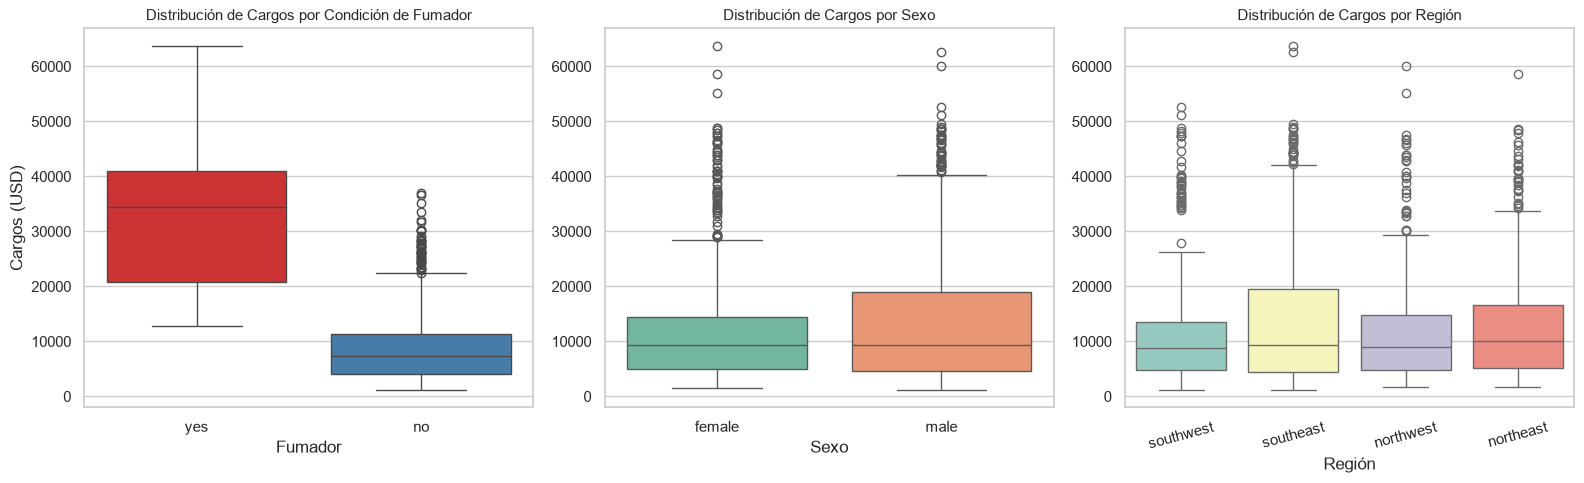

Promedio de charges por grupo:

Por fumador:
 smoker
no      8441.0
yes    32050.0
Name: charges, dtype: float64 

Por sexo:
 sex
female    12570.0
male      13975.0
Name: charges, dtype: float64 

Por region:
 region
northeast    13406.0
northwest    12451.0
southeast    14735.0
southwest    12347.0
Name: charges, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Por fumador
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[0], hue="smoker", palette="Set1", legend=False)
axes[0].set_title("Distribución de Cargos por Condición de Fumador", fontsize=11)
axes[0].set_xlabel("Fumador")
axes[0].set_ylabel("Cargos (USD)")

# 2. Por sexo
sns.boxplot(data=df, x="sex", y="charges", ax=axes[1], hue="sex", palette="Set2", legend=False)
axes[1].set_title("Distribución de Cargos por Sexo", fontsize=11)
axes[1].set_xlabel("Sexo")
axes[1].set_ylabel("")

# 3. Por región
sns.boxplot(data=df, x="region", y="charges", ax=axes[2], hue="region", palette="Set3", legend=False)
axes[2].set_title("Distribución de Cargos por Región", fontsize=11)
axes[2].set_xlabel("Región")
axes[2].set_ylabel("")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_charges_por_grupo.png", dpi=150, bbox_inches="tight")
plt.show()

# Promedios de respaldo
print("Promedio de charges por grupo:\n")
print("Por fumador:\n", df.groupby("smoker")["charges"].mean().round(0), "\n")
print("Por sexo:\n", df.groupby("sex")["charges"].mean().round(0), "\n")
print("Por region:\n", df.groupby("region")["charges"].mean().round(0))

La diferencia por `smoker` es enorme: un fumador paga en promedio 32,050 dólares contra 8,441 de un no fumador, casi 4 veces más. La caja de los fumadores está toda por arriba y casi no se traslapa con la de los no fumadores.

Por `sex` la diferencia es pequeña (los hombres pagan un poquito más en promedio, 13,975 contra 12,570, más que nada por algunos casos extremos en su cola). 

Y por `region` tampoco hay gran diferencia, aunque southeast queda un poco arriba (14,735). Todo esto encaja con las correlaciones: sexo y región salían casi en cero, y aquí se confirma que casi no mueven la aguja.

## 4. Un vistazo a la multicolinealidad

Revisamos si las variables independientes se correlacionan entre sí de forma alta, ya que eso puede afectar análisis posteriores de regresión.

In [8]:
corr_X = df_numerico.drop(columns="charges").corr().abs()
import itertools
pares = []
cols = corr_X.columns
for a, b in itertools.combinations(cols, 2):
    pares.append((round(corr_X.loc[a, b], 3), a, b))

print("Pares de variables X más correlacionados entre sí:")
for v, a, b in sorted(pares, reverse=True)[:5]:
    print(f"  {a} ~ {b}: {v}")

Pares de variables X más correlacionados entre sí:
  region_southeast ~ region_southwest: 0.347
  region_northwest ~ region_southeast: 0.346
  region_northwest ~ region_southwest: 0.32
  bmi ~ region_southeast: 0.27
  bmi ~ region_northwest: 0.136


Las correlaciones más altas entre variables X son entre las columnas de región (alrededor de 0.35), y eso es normal porque salen de una misma variable partida en one-hot. 

Fuera de eso no hay nada preocupante, así que para la regresión del Día 4 no deberíamos tener problemas serios de multicolinealidad.